In [37]:
import pandas as pd 
import numpy as np
import keras
from keras.preprocessing import image
from tensorflow.keras.utils import to_categorical
import os
from PIL import Image
import matplotlib as plt

In [25]:
image_files = []

# go through all the folders
for folder in os.listdir():

    # filter out all files and git folder
    if "." not in folder:

        # specify the path
        path = os.getcwd() + "\\" + folder + "\\"

        # go through all the files
        for file in os.listdir(path):
            
            # specify the image file name
            image_file = path + "\\" + file 

            # load the image and append it to initial list
            img = Image.open(image_file)

            # specify the list to append to the final list
            image_files.append([img, folder])

In [26]:
# create dataframe with 2-D list

data = pd.DataFrame(image_files, columns = ["image_object", "target_class"])

In [27]:
data["target_class"].unique()

array(['fully_covered', 'not_covered', 'not_face', 'partially_covered'],
      dtype=object)

In [28]:
# one hot encode values

one_hot_encoder = {'fully_covered':0, 'not_covered':1, 'not_face':2, 'partially_covered':3}

data["target_class_ohe"] = data["target_class"].apply(lambda d: one_hot_encoder[d])

In [29]:
# investigate images data by setting columns

data["filename"] = data["image_object"].apply(lambda d: d.filename)

data["height_pixels"] = data["image_object"].apply(lambda d: d.height)

data["width_pixels"] = data["image_object"].apply(lambda d: d.width)

data["mode"] = data["image_object"].apply(lambda d: d.mode)

<AxesSubplot:>

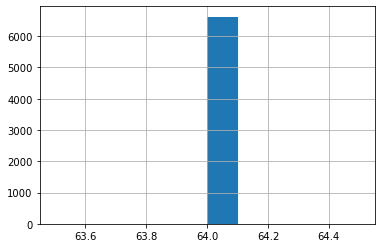

In [30]:
# histogram for height pixels

data["height_pixels"].hist()

All images have the same height in pixels (64), not resizing needed

<AxesSubplot:>

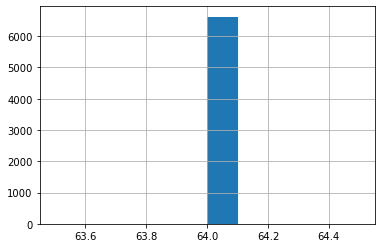

In [31]:
# histogram for height pixels

data["width_pixels"].hist()

All images have the same width in pixels (64), not resizing needed

In [32]:
data["mode"].unique()

array(['L'], dtype=object)

All images are in black and white therefore the depth of the arrays will be 2

Make each image into an array (since the images are black and white they will only be 1 dimensional)

In [33]:
# create column for arrays 

data["array"] = data["image_object"].apply(lambda d: image.img_to_array(d))

data["gs_array"] = data["image_object"].apply(lambda d: image.img_to_array(d) / 255)

# Create train and test splits

In [34]:
# make X into a new array

X_list = []

for image_object in data["gs_array"]:
    img_array = image.img_to_array(image_object)
    img_array /= 255
    X_list.append(img_array)

X = np.array(X_list)

In [38]:
# Create y array

y = data["target_class_ohe"].values
y = to_categorical(y)

In [44]:
y

array([[1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       ...,
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.]], dtype=float32)

In [39]:
# Create training and test arrays

from sklearn.model_selection import train_test_split

test_size = 0.15

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, test_size = test_size)

# Create model

In [40]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D

In [47]:
# add layers to the model

model = Sequential()
#first layer - input_shape is necessary
model.add(Conv2D(filters = 32, kernel_size = (3, 3), activation = 'relu', input_shape = (64,64,1)))
model.add(Conv2D(filters = 64, kernel_size = (3, 3), activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2, 2)))
model.add(Flatten())
model.add(Dense(128, activation = 'relu'))
model.add(Dense(4, activation = 'softmax'))

In [48]:
#compiling

model.compile(loss='categorical_crossentropy', optimizer='Adam', metrics=['accuracy'])

In [51]:
# fit the model

model.fit(X_train, y_train, epochs = 10, validation_split = 0.10)

Epoch 1/10
159/159 [==============================] - 30s 183ms/step - loss: 1.1412 - accuracy: 0.5551 - val_loss: 1.1862 - val_accuracy: 0.5382
Epoch 2/10
159/159 [==============================] - 30s 190ms/step - loss: 1.0282 - accuracy: 0.5942 - val_loss: 0.8634 - val_accuracy: 0.6430
Epoch 3/10
159/159 [==============================] - 29s 181ms/step - loss: 0.6961 - accuracy: 0.7273 - val_loss: 0.6643 - val_accuracy: 0.7442
Epoch 4/10
159/159 [==============================] - 29s 181ms/step - loss: 0.5546 - accuracy: 0.7903 - val_loss: 0.5670 - val_accuracy: 0.7886
Epoch 5/10
159/159 [==============================] - 28s 177ms/step - loss: 0.4696 - accuracy: 0.8241 - val_loss: 0.4875 - val_accuracy: 0.8384
Epoch 6/10
159/159 [==============================] - 27s 172ms/step - loss: 0.4168 - accuracy: 0.8481 - val_loss: 0.4425 - val_accuracy: 0.8615
Epoch 7/10
159/159 [==============================] - 27s 168ms/step - loss: 0.3752 - accuracy: 0.8679 - val_loss: 0.4031 - val_ac